Our quantifications match the visualization -- subsetting to the test conditions of interest in a given fold

In [1]:
import warnings

warnings.resetwarnings()

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*__version__ is deprecated.*"
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"Observation names are not unique.*"
)

warnings.filterwarnings(
    "ignore",
    module=r"scanpy(\..*)?$"
)

warnings.filterwarnings(
    "ignore",
    module=r"anndata(\..*)?$"
)

warnings.filterwarnings("ignore", module=r"scanpy(\..*)?$")
warnings.filterwarnings("ignore", module=r"anndata(\..*)?$")
warnings.filterwarnings("ignore", message="Observation names are not unique.*")
warnings.filterwarnings("ignore", message="`__version__` is deprecated.*")
warnings.filterwarnings('ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ImportWarning)

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings(
    "ignore",
    category=ImplicitModificationWarning
)

In [2]:
import os
import sys
import warnings
import copy
from collections import defaultdict

from tqdm import trange

import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cosine as cosine_distance
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 12,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, pb_y_pred

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.metrics import distances

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [4]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

merged_adatas_rand = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_rand_predictions.pickle'.format(author))
)



In [5]:
n_folds = 5

# Cosine Distance

We will use Systema[https://www.nature.com/articles/s41587-025-02777-8] cosine distance metric to quantify this condition space relative to the random baseline

The above visualizations can be quantified relative to the random baseline, showing that we are capturing the relative global geometry of the perturbation space accurately. 

This metric most accurately reflects the visualization comparison we conducted in Notebook 01Ai

In [28]:
def pert_centroids(adata, pls_model = None):
    if pls_model is None:
        X = adata.to_df()
    else:
        X = pd.DataFrame(pls_model.transform(adata.X), 
                         index = adata.obs_names, 
                         columns = ['LV{}'.format(i+1) for i in range(pls_model.n_components)]
                        )
    X[pert_col] = adata.obs[pert_col].astype(str).tolist()
    X = X.groupby(pert_col).mean()
    
    return X

def get_cos_dist(fold, tf_adata_merged, pls_model = None):
    distances = defaultdict(list)
    
    split = get_split(fold, author)
    test_conds = split['test_conds']
    ctrl_conds = list({'^'.join([tc.split('^')[0], ctrl_pert]) for tc in test_conds})

    cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[cond_mask, :].copy()
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')

    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy() #predicted test conditions only
    tf_adata_actual_pert = tf_adata[tf_adata.obs.condition.isin(test_conds), :] # actual data
    tf_adata_actual_ctrl = tf_adata[tf_adata.obs.condition.isin(ctrl_conds), :] # corresponding controls

    X_pred = pert_centroids(tf_adata_predicted, pls_model = pls_model)
    X_actual_pert = pert_centroids(tf_adata_actual_pert, pls_model = pls_model)
    assert sorted(X_pred.index) == sorted(X_actual_pert.index), 'Test conditions are not consistent'

    if pls_model is None:
        all_pert_centroid = tf_adata_actual_pert.to_df().mean(axis = 0).values 
    else:
        all_pert_centroid = pd.DataFrame(
            pls_model.transform(tf_adata_actual_pert.X), 
            index = tf_adata_actual_pert.obs_names, 
            columns = ['LV{}'.format(i+1) for i in range(pls_model.n_components)]
                        )
        all_pert_centroid = all_pert_centroid.mean(axis = 0).values
        
    ctrl_centroid = pert_centroids(tf_adata_actual_ctrl, pls_model = pls_model).values[0]

    X_pred = X_pred.loc[X_actual_pert.index, :].copy()

    for pert in X_pred.index:
        actual_pert_centroid = X_actual_pert.loc[pert, :].values
        pred_pert_centroid = X_pred.loc[pert, :].values

        v_actual_pert = actual_pert_centroid - ctrl_centroid
        v_ctrl = all_pert_centroid - ctrl_centroid
        cos_dist_actual = cosine_distance(v_actual_pert, v_ctrl)

        v_pred_pert = pred_pert_centroid - ctrl_centroid
        cos_dist_pred = cosine_distance(v_pred_pert, v_ctrl)
        
        distances['fold'].append(fold)
        distances['perturbation'].append(pert)
        distances['actual'].append(cos_dist_actual)
        distances['predicted'].append(cos_dist_pred)
    
    return pd.DataFrame(distances)

def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)


## Full Feature Space

Because the Systema metric requires controls, we either need to use the full feature space, or a PLS fit on test conditions AND the corresponding controls, which is different from what was used in the visualization of 01Ai (pls models of just test conditions).

In [32]:
distances = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key].copy()
    
    
    distances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = None)
    distances.append(distances_fold)
    
distances = pd.concat(distances, ignore_index = True)
distances['mod_type'] = 'actual'

distances_rand = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas_rand[key].copy()
    
    
    distnances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = None)
    distances_rand.append(distnances_fold)
    
distances_rand = pd.concat(distances_rand, ignore_index = True)
distances_rand['mod_type'] = 'random'

distances = pd.concat([distances, distances_rand], ignore_index = True)
cos_distances = distances
cos_distances['error'] = np.abs(cos_distances["predicted"] - cos_distances["actual"]) #/ np.sqrt(2)
cos_distances.mod_type = pd.Categorical(
    cos_distances.mod_type, 
    categories = ['actual', 'random'], 
    ordered = True
)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 15.18it/s]


''

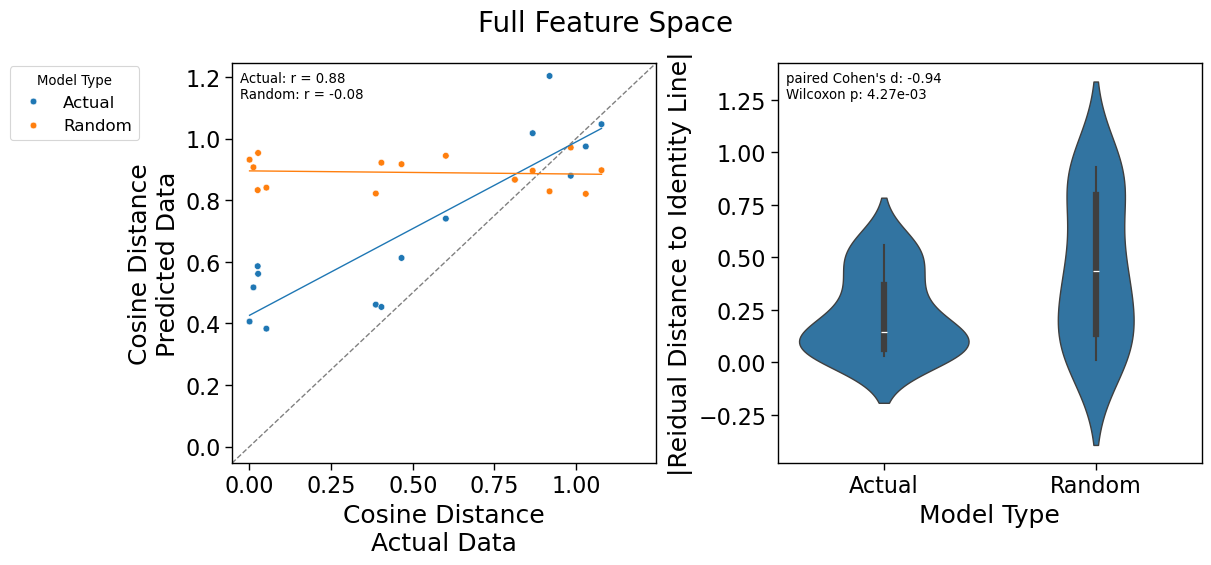

In [25]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5), constrained_layout = True)

j = 0
sns.scatterplot(data = cos_distances, x = 'actual', y = 'predicted', hue = 'mod_type', ax = ax[j], zorder = 2)

for mod_type in ['actual', 'random']:
    viz_df = cos_distances[cos_distances.mod_type == mod_type].copy()

    sns.regplot(
        data=viz_df,
        x="actual",
        y="predicted",
        ax=ax[j],
        scatter=False,      
        ci = None,
        line_kws={"linewidth": 1}, 
    )

    
# pearson
pr_actual = stats.pearsonr(cos_distances[cos_distances.mod_type == 'actual'].actual,
                           cos_distances[cos_distances.mod_type == 'actual'].predicted).statistic
pr_noadv = stats.pearsonr(cos_distances[cos_distances.mod_type == 'random'].actual,
                          cos_distances[cos_distances.mod_type == 'random'].predicted).statistic

ax[j].text(
    0.02, 0.98,
    "{}: r = {:.2f}\n{}: r = {:.2f}".format('Actual', pr_actual, 'Random', pr_noadv),
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ax[j].set_xlabel('Cosine Distance\nActual Data')
ax[j].set_ylabel('Cosine Distance\nPredicted Data')

xmin, xmax = ax[j].get_xlim()
ymin, ymax = ax[j].get_ylim()

ax_min = min(xmin, ymin)
ax_max = max(xmax, ymax)

ax[j].set_xlim(ax_min, ax_max)
ax[j].set_ylim(ax_min, ax_max)

ax[j].plot(
    [ax_min, ax_max],
    [ax_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)


handles, labels = ax[j].get_legend_handles_labels()
ax[j].legend(
    handles = handles, labels = ['Actual', 'Random'], title = 'Model Type', 
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)


j = 1
a = cos_distances[cos_distances.mod_type == 'actual']['error'].values
b = cos_distances[cos_distances.mod_type == 'random']['error'].values
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b).pvalue


sns.violinplot(data = cos_distances, x = 'mod_type', y = 'error', ax = ax[j])
ax[j].set_xlabel('Residual Distance')
ax[j].set_xlabel('Model Type')


ax[j].text(
    0.02, 0.98,
    f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ticks = ax[j].get_xticks()
ax[j].set_xticks(ticks)
ax[j].set_xticklabels(['Actual', 'Random'])
ax[j].set_ylabel('|Reidual Distance to Identity Line|')

fig.suptitle('Full Feature Space', y = 1.1, fontsize = 20)
;

## PLS Space

We repeat the analysis in PLS space. Note, these PLS models were fit on the test conditions AND their corresponding controls (because the Systema metric requires controls). This is different from what was used in teh visualization of 01Ai (pls models of just test conditions).

In [26]:
cspcm = io.read_pickled_object(
    os.path.join(data_path, 'interim', '{}_test_condition_PLS_models_with_control.pickle')
)

In [29]:
distances = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key].copy()
    
    
    distances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = cspcm[fold])
    distances.append(distances_fold)
    
distances = pd.concat(distances, ignore_index = True)
distances['mod_type'] = 'actual'

distances_rand = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas_rand[key].copy()
    
    
    distnances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = cspcm[fold])
    distances_rand.append(distnances_fold)
    
distances_rand = pd.concat(distances_rand, ignore_index = True)
distances_rand['mod_type'] = 'random'

distances = pd.concat([distances, distances_rand], ignore_index = True)
cos_distances = distances
cos_distances['error'] = np.abs(cos_distances["predicted"] - cos_distances["actual"]) #/ np.sqrt(2)
cos_distances.mod_type = pd.Categorical(
    cos_distances.mod_type, 
    categories = ['actual', 'random'], 
    ordered = True
)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 10.09it/s]


''

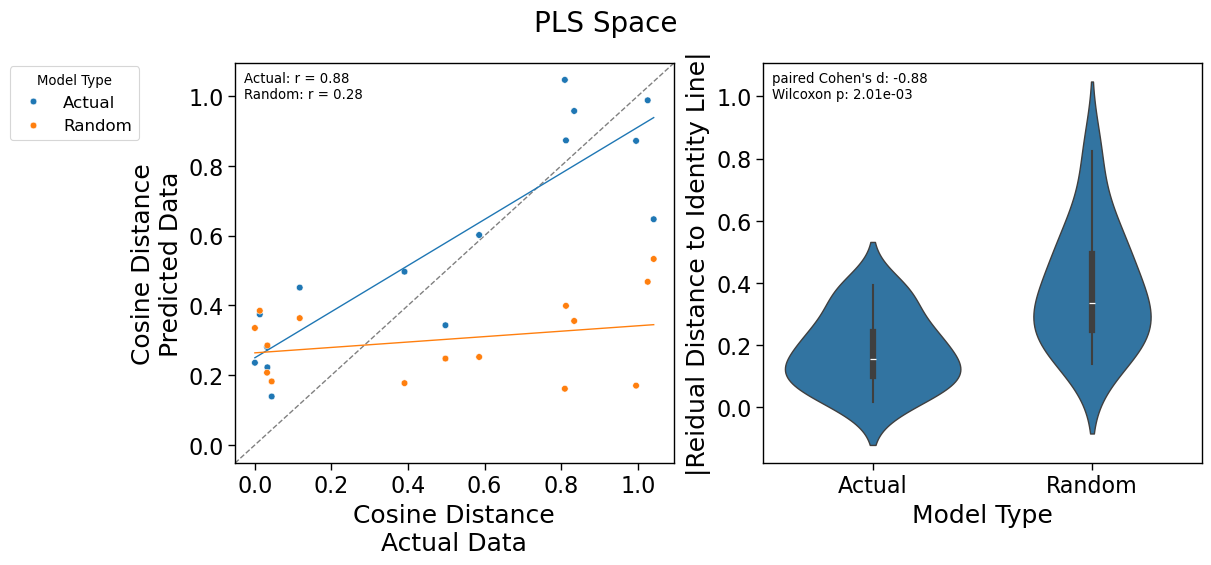

In [30]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5), constrained_layout = True)

j = 0
sns.scatterplot(data = cos_distances, x = 'actual', y = 'predicted', hue = 'mod_type', ax = ax[j], zorder = 2)

for mod_type in ['actual', 'random']:
    viz_df = cos_distances[cos_distances.mod_type == mod_type].copy()

    sns.regplot(
        data=viz_df,
        x="actual",
        y="predicted",
        ax=ax[j],
        scatter=False,      
        ci = None,
        line_kws={"linewidth": 1}, 
    )

    
# pearson
pr_actual = stats.pearsonr(cos_distances[cos_distances.mod_type == 'actual'].actual,
                           cos_distances[cos_distances.mod_type == 'actual'].predicted).statistic
pr_noadv = stats.pearsonr(cos_distances[cos_distances.mod_type == 'random'].actual,
                          cos_distances[cos_distances.mod_type == 'random'].predicted).statistic

ax[j].text(
    0.02, 0.98,
    "{}: r = {:.2f}\n{}: r = {:.2f}".format('Actual', pr_actual, 'Random', pr_noadv),
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ax[j].set_xlabel('Cosine Distance\nActual Data')
ax[j].set_ylabel('Cosine Distance\nPredicted Data')

xmin, xmax = ax[j].get_xlim()
ymin, ymax = ax[j].get_ylim()

ax_min = min(xmin, ymin)
ax_max = max(xmax, ymax)

ax[j].set_xlim(ax_min, ax_max)
ax[j].set_ylim(ax_min, ax_max)

ax[j].plot(
    [ax_min, ax_max],
    [ax_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)


handles, labels = ax[j].get_legend_handles_labels()
ax[j].legend(
    handles = handles, labels = ['Actual', 'Random'], title = 'Model Type', 
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)


j = 1
a = cos_distances[cos_distances.mod_type == 'actual']['error'].values
b = cos_distances[cos_distances.mod_type == 'random']['error'].values
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b).pvalue


sns.violinplot(data = cos_distances, x = 'mod_type', y = 'error', ax = ax[j])
ax[j].set_xlabel('Residual Distance')
ax[j].set_xlabel('Model Type')


ax[j].text(
    0.02, 0.98,
    f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ticks = ax[j].get_xticks()
ax[j].set_xticks(ticks)
ax[j].set_xticklabels(['Actual', 'Random'])
ax[j].set_ylabel('|Reidual Distance to Identity Line|')

fig.suptitle('PLS Space', y = 1.1, fontsize = 20)
;